# Creating Cohorts of Songs
A conversational, notebook-style analysis for cohorting songs using Spotify audio features.

Notebook covers: inspection & cleaning, refinement, EDA, dimensionality reduction, and clustering.

## 1) Initial data inspection
Load the CSV and display quick diagnostics.

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path('datasets') / 'rolling_stones_spotify.csv'
print('Reading:', data_path)
df = pd.read_csv(data_path)
# quick overview
print('shape:', df.shape)
print('\nhead:')
print(df.head().to_string())
print('\ncolumn dtypes:')
print(df.dtypes)
print('\nsummary stats (numeric):')
print(df.describe(include='all').to_string())
print('\nmissing values per column:')
print(df.isna().sum())
print('\nexact duplicate rows:', df.duplicated().sum())

Reading: datasets\rolling_stones_spotify.csv
shape: (1610, 18)

head:
   Unnamed: 0                         name               album release_date  track_number                      id                                   uri  acousticness  danceability  energy  instrumentalness  liveness  loudness  speechiness    tempo  valence  popularity  duration_ms
0           0   Concert Intro Music - Live  Licked Live In NYC   2022-06-10             1  2IEkywLJ4ykbhi1yRQvmsT  spotify:track:2IEkywLJ4ykbhi1yRQvmsT        0.0824         0.463   0.993          0.996000     0.932   -12.913       0.1100  118.001   0.0302          33        48640
1           1   Street Fighting Man - Live  Licked Live In NYC   2022-06-10             2  6GVgVJBKkGJoRfarYRvGTU  spotify:track:6GVgVJBKkGJoRfarYRvGTU        0.4370         0.326   0.965          0.233000     0.961    -4.803       0.0759  131.455   0.3180          34       253173
2           2           Start Me Up - Live  Licked Live In NYC   2022-06-10         

## 1b) Conservative cleaning
I'll perform a conservative clean: drop exact duplicates, coerce numeric types, clip popularity, mark obvious bad durations, and flag outliers (but not delete).

In [25]:
df_clean = df.copy()
# drop exact duplicates
dups_before = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'duplicates dropped: {dups_before} -> {int(df_clean.duplicated().sum())}')
# require at least one identifier (name/title/track)
key_cols = [c for c in ('track_name','track','title','artist','name') if c in df_clean.columns]
if key_cols:
    before = len(df_clean)
    mask = pd.Series(True, index=df_clean.index)
    for c in key_cols[:2]:
        if c in df_clean.columns:
            mask = mask & df_clean[c].notna()
    df_clean = df_clean[mask].reset_index(drop=True)
    print(f'rows removed for missing key identifier (first-two required): {before - len(df_clean)}')
# coerce likely numeric columns
numeric_candidates = ['acousticness','danceability','energy','instrumentalness','liveness','loudness','speechiness','tempo','valence','popularity','duration_ms','duration']
for col in numeric_candidates:
    if col in df_clean.columns and not np.issubdtype(df_clean[col].dtype, np.number):
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
# clip popularity
if 'popularity' in df_clean.columns:
    pop_invalid = int(((df_clean['popularity'] < 0) | (df_clean['popularity'] > 100)).sum())
    df_clean.loc[df_clean['popularity'] < 0, 'popularity'] = 0
    df_clean.loc[df_clean['popularity'] > 100, 'popularity'] = 100
    print(f'popularity values corrected (clipped): {pop_invalid}')
# handle negative durations
if 'duration_ms' in df_clean.columns:
    neg_dur = int((df_clean['duration_ms'] < 0).sum())
    df_clean.loc[df_clean['duration_ms'] < 0, 'duration_ms'] = np.nan
    print(f'negative durations set to NaN: {neg_dur}')
# flag outliers (z-score without SciPy)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    vals = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
    z = np.abs((vals - vals.mean()) / vals.std(ddof=0))
    if z.ndim == 1:
        outlier_mask = z > 3
    else:
        outlier_mask = (z > 3).any(axis=1)
    df_clean['outlier_flag'] = outlier_mask
    print('outliers flagged (z>3):', int(df_clean['outlier_flag'].sum()))
print('\nmissing values after cleaning:')
print(df_clean.isna().sum())
cleaned_df = df_clean

duplicates dropped: 0 -> 0
rows removed for missing key identifier (first-two required): 0
popularity values corrected (clipped): 0
negative durations set to NaN: 0
outliers flagged (z>3): 125

missing values after cleaning:
Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
outlier_flag        0
dtype: int64


### Cleaning ΓÇö quick notes
I kept cleaning conservative: no deletions beyond exact duplicates and missing identifier enforcement. Outliers are flagged for later handling.

## 2) Data refinement
Select features and prepare the final matrix for downstream analysis (winsorize + transforms + scaling).

In [26]:
# feature selection and transforms
features = ['acousticness','danceability','energy','instrumentalness','liveness','loudness','speechiness','tempo','valence','popularity','duration_ms']
available = [f for f in features if f in cleaned_df.columns]
print('selected features:', available)
df_feat = cleaned_df[available].copy()
for c in df_feat.columns:
    df_feat[c] = pd.to_numeric(df_feat[c], errors='coerce')
# duration transforms
if 'duration_ms' in df_feat.columns:
    df_feat['duration_s'] = df_feat['duration_ms'] / 1000.0
    df_feat['log_duration_s'] = np.log1p(df_feat['duration_s'])
# winsorize at 1%/99%
numeric_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
q_low = df_feat[numeric_cols].quantile(0.01)
q_high = df_feat[numeric_cols].quantile(0.99)
df_wins = df_feat.copy()
for c in numeric_cols:
    df_wins[c] = df_wins[c].clip(lower=q_low[c], upper=q_high[c])
# scale features (StandardScaler if available)
try:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = df_wins[numeric_cols].fillna(df_wins[numeric_cols].median())
    X_scaled = scaler.fit_transform(X)
    print('StandardScaler used')
except Exception:
    X = df_wins[numeric_cols].fillna(df_wins[numeric_cols].median())
    X_scaled = (X - X.mean())/X.std(ddof=0)
    X_scaled = X_scaled.values
    print('Fallback scaling used')
# Save refined outputs
save_dir = Path('datasets')
df_wins.to_csv(save_dir / 'rolling_stones_spotify_refined.csv', index=False)
import numpy as _np
_np.save(save_dir / 'rolling_stones_spotify_scaled.npy', X_scaled)
print('refined saved:', (save_dir / 'rolling_stones_spotify_refined.csv'))
print('scaled saved:', (save_dir / 'rolling_stones_spotify_scaled.npy'))
df_for_clustering = df_wins.copy()

selected features: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']
StandardScaler used
refined saved: datasets\rolling_stones_spotify_refined.csv
scaled saved: datasets\rolling_stones_spotify_scaled.npy


### Data refinement ΓÇö quick notes
I kept `outlier_flag` in the original dataframe so we can inspect later; the refined file has winsorized numeric features and the duration log transform.

## 3) Exploratory data analysis and feature engineering
Quick EDA: summary stats, distributions, and pick two albums to recommend based on popular songs.

       acousticness  danceability       energy  instrumentalness     liveness     loudness  speechiness        tempo      valence   popularity    duration_ms   duration_s  log_duration_s
count   1610.000000   1610.000000  1610.000000       1610.000000  1610.000000  1610.000000  1610.000000  1610.000000  1610.000000  1610.000000    1610.000000  1610.000000     1610.000000
mean       0.249931      0.468801     0.792812          0.163921     0.491786    -6.941210     0.068636   126.096763     0.582460    20.685714  257103.931913   257.103932        5.484181
std        0.225843      0.140176     0.178425          0.275529     0.348929     2.863151     0.046189    28.979276     0.230438    12.045561  102165.243497   102.165243        0.368750
min        0.000279      0.179180     0.300000          0.000000     0.042908   -14.696000     0.025618    71.910370     0.062658     0.090000   94014.170000    94.014170        4.554026
25%        0.058350      0.362250     0.674000          0.000219 

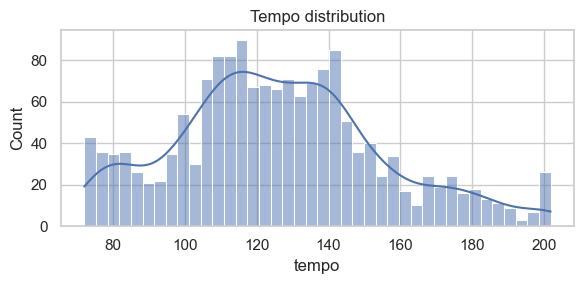


Top albums by number of popular songs (popularity>=50):
album
Sticky Fingers (Remastered)                   6
Exile On Main Street (2010 Re-Mastered)       4
Let It Bleed                                  4
Out Of Our Heads                              3
Tattoo You (2009 Re-Mastered)                 3
Some Girls                                    3
Between The Buttons                           2
Emotional Rescue (2009 Re-Mastered)           2
Beggars Banquet (50th Anniversary Edition)    2
Aftermath                                     2

Recommended albums (top 2): ['Sticky Fingers (Remastered)', 'Exile On Main Street (2010 Re-Mastered)']


C:\Users\pbvw\AppData\Local\Temp\ipykernel_33328\406547789.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_counts.values[:10], y=popular_counts.index[:10], palette='viridis')


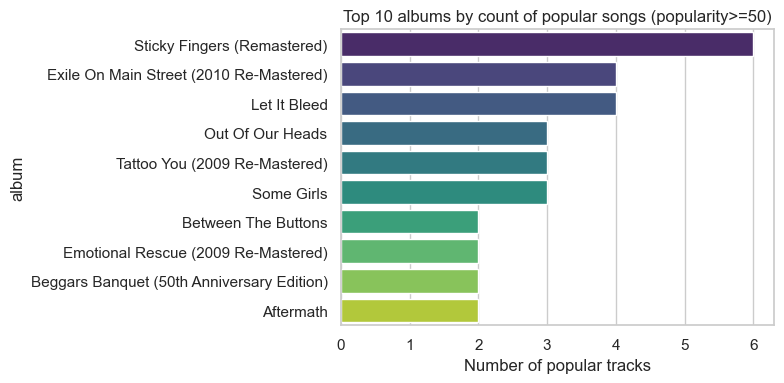

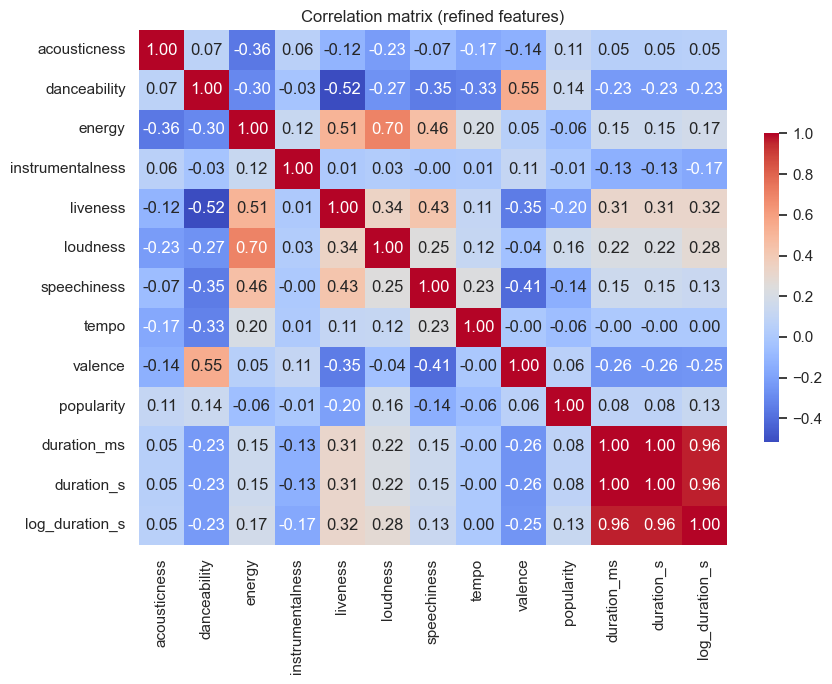

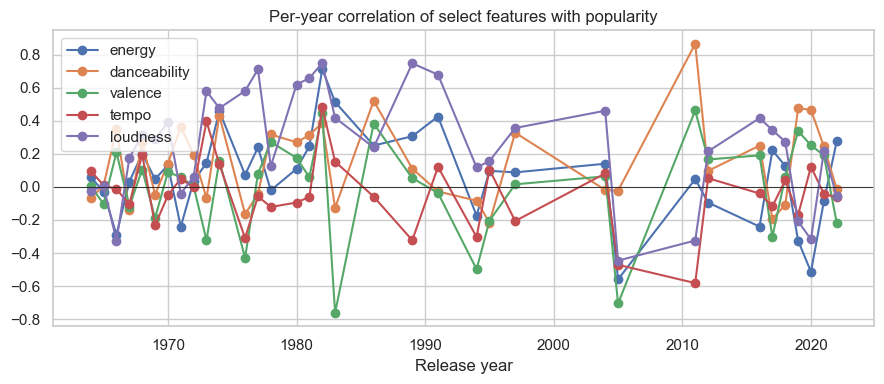

Per-year correlation (last 10 years shown):
        energy  danceability   valence     tempo  loudness
year                                                      
2005 -0.559687     -0.022951 -0.705318 -0.471293 -0.445973
2011  0.047557      0.866582  0.463252 -0.582231 -0.324271
2012 -0.094376      0.097548  0.166396  0.052932  0.215729
2016 -0.240062      0.250374  0.191384 -0.039437  0.416769
2017  0.221759     -0.192883 -0.301604 -0.117307  0.345089
2018  0.127846     -0.108481  0.059926  0.040394  0.273469
2019 -0.325087      0.476154  0.338060 -0.169558 -0.207945
2020 -0.514019      0.467347  0.252570  0.122584 -0.317247
2021 -0.087862      0.245241  0.191631 -0.041837  0.215518
2022  0.275838     -0.011585 -0.216350 -0.063085 -0.055900


In [27]:
# summary stats for refined features
print(df_for_clustering.describe(include='all').to_string())
# distributions and EDA plots
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
# example: tempo distribution
plt.figure(figsize=(6,3))
sns.histplot(df_for_clustering['tempo'].dropna(), kde=True, bins=40)
plt.title('Tempo distribution')
plt.tight_layout()
plt.show()
plt.close()
# popularity by album: define popular as popularity >= 50 (tunable)
if 'popularity' in df_for_clustering.columns and 'album' in df.columns:
    df_with_meta = df.copy()
    df_with_meta['is_popular'] = df_with_meta['popularity'] >= 50
    popular_counts = df_with_meta.groupby('album')['is_popular'].sum().sort_values(ascending=False)
    print('\nTop albums by number of popular songs (popularity>=50):')
    print(popular_counts.head(10).to_string())
    top2 = popular_counts.head(2).index.tolist()
    print('\nRecommended albums (top 2):', top2)
    # bar chart of top albums
    plt.figure(figsize=(8,4))
    sns.barplot(x=popular_counts.values[:10], y=popular_counts.index[:10], palette='viridis')
    plt.title('Top 10 albums by count of popular songs (popularity>=50)')
    plt.xlabel('Number of popular tracks')
    plt.tight_layout()
    plt.show()
    plt.close()
# correlation heatmap for numeric features
numeric_cols = df_for_clustering.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    corr = df_for_clustering[numeric_cols].corr()
    plt.figure(figsize=(9,7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink':0.6})
    plt.title('Correlation matrix (refined features)')
    plt.tight_layout()
    plt.show()
    plt.close()
# Per-year correlation of select features with popularity (how correlation evolved)
if 'release_date' in df.columns:
    df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    features_to_track = [f for f in ['energy','danceability','valence','tempo','loudness'] if f in df.columns]
    years = sorted(df['release_year'].dropna().unique())
    year_corrs = []
    for y in years:
        sub = df[df['release_year'] == y]
        if len(sub) >= 5:
            row = {'year': int(y)}
            for f in features_to_track:
                row[f] = sub[f].corr(sub['popularity']) if 'popularity' in sub.columns else np.nan
            year_corrs.append(row)
    if year_corrs:
        year_corrs = pd.DataFrame(year_corrs).set_index('year').sort_index()
        plt.figure(figsize=(9,4))
        for f in year_corrs.columns:
            plt.plot(year_corrs.index, year_corrs[f], marker='o', label=f)
        plt.axhline(0, color='k', linewidth=0.6)
        plt.legend()
        plt.title('Per-year correlation of select features with popularity')
        plt.xlabel('Release year')
        plt.tight_layout()
        plt.show()
        plt.close()
        print('Per-year correlation (last 10 years shown):')
        print(year_corrs.tail(10).to_string())
    else:
        print('Not enough per-year data to compute correlations.')

### Recommendation rationale (journal)
I chose albums with the highest count of tracks meeting a popularity threshold (popularity>=50). This is a pragmatic proxy for what a general listener might enjoy. We can refine the threshold or use top-percentile selection if you prefer.

## 3b) Relationships & popularity analysis
Explore how features relate to popularity and each other.

In [28]:
# correlations with popularity
if 'popularity' in df_for_clustering.columns:
    corr = df_for_clustering.corr()['popularity'].sort_values(ascending=False)
    print('Feature correlation with popularity:')
    print(corr.to_string())
# pairwise scatter example (tempo vs energy)
plt.figure(figsize=(5,4))
if 'tempo' in df_for_clustering.columns and 'energy' in df_for_clustering.columns:
    sns.scatterplot(x=df_for_clustering['tempo'], y=df_for_clustering['energy'], alpha=0.6)
    plt.title('Tempo vs Energy')
    plt.tight_layout()
    plt.close()

Feature correlation with popularity:
popularity          1.000000
loudness            0.159842
danceability        0.137844
log_duration_s      0.125250
acousticness        0.108862
duration_ms         0.078808
duration_s          0.078808
valence             0.063277
instrumentalness   -0.007249
energy             -0.057309
tempo              -0.063436
speechiness        -0.142604
liveness           -0.204477


### Dimensionality reduction note
We'll use PCA to create a low-dimensional view for visualization and to speed up clustering when appropriate. PCA preserves variance structure and helps identify feature redundancies.

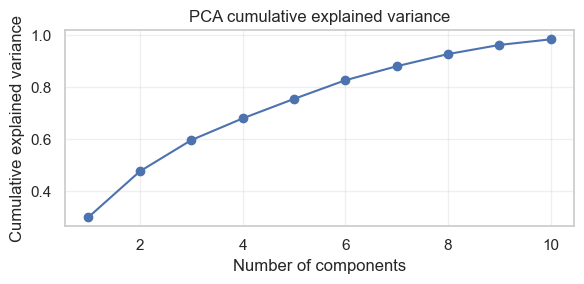

PCA explained variance ratio (2 components): [0.29915999 0.17625191]


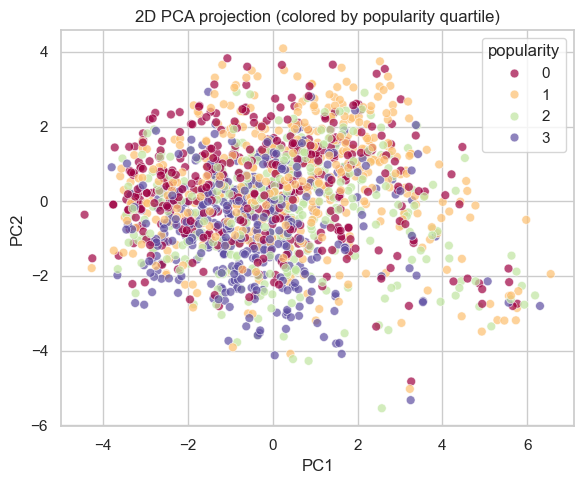

In [29]:
# PCA for visualization (scree and 2D scatter)
try:
    from sklearn.decomposition import PCA
    n_comp = min(10, X_scaled.shape[1])
    pca_full = PCA(n_components=n_comp)
    X_pca_full = pca_full.fit_transform(X_scaled)
    evr = pca_full.explained_variance_ratio_
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,3))
    plt.plot(range(1, len(evr)+1), evr.cumsum(), marker='o')
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title('PCA cumulative explained variance')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()
    # 2-component projection for visualization
    pca2 = PCA(n_components=2)
    X_pca = pca2.fit_transform(X_scaled)
    print('PCA explained variance ratio (2 components):', pca2.explained_variance_ratio_)
    # color by popularity quartile if available
    import numpy as _np
    if 'popularity' in df_for_clustering.columns:
        pop_q = pd.qcut(df_for_clustering['popularity'].fillna(0), q=4, labels=False, duplicates='drop')
    else:
        pop_q = _np.zeros(X_pca.shape[0])
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=pop_q, palette='Spectral', alpha=0.7, s=40, legend='brief')
    plt.title('2D PCA projection (colored by popularity quartile)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()
    plt.close()
except Exception as e:
    print('PCA skipped (sklearn not available):', e)

## 4) Cluster analysis
Use elbow & silhouette to choose k, then run KMeans and describe clusters.

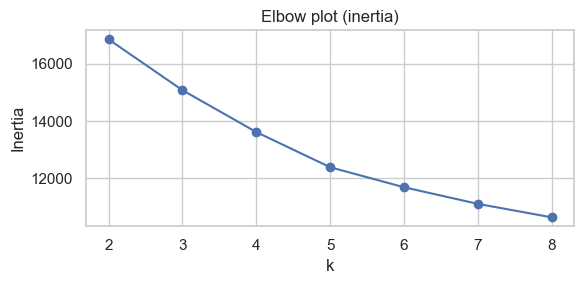

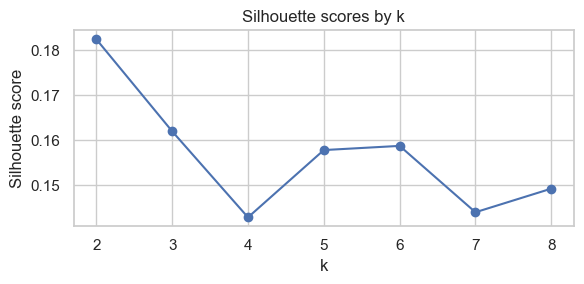

silhouette (k>1): {2: 0.18239817409296824, 3: 0.16198478434213257, 4: 0.14289768134830916, 5: 0.1578253301332397, 6: 0.1587528872148331, 7: 0.1440290876619362, 8: 0.14926498987927486}
Chosen k based on silhouette: 2
Assigned cluster labels with k=2


In [30]:
# determine k with elbow and silhouette (small sweep)
k_candidates = list(range(2,9))
inertia = []
sil_scores = {}
try:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    for k in k_candidates:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
        inertia.append(km.inertia_)
        if k > 1:
            sil_scores[k] = silhouette_score(X_scaled, km.labels_)
    # plot elbow (inertia)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,3))
    plt.plot(k_candidates, inertia, marker='o')
    plt.xlabel('k')
    plt.ylabel('Inertia')
    plt.title('Elbow plot (inertia)')
    plt.tight_layout()
    plt.show()
    plt.close()
    # plot silhouette scores
    if sil_scores:
        ks = sorted(sil_scores.keys())
        vals = [sil_scores[k] for k in ks]
        plt.figure(figsize=(6,3))
        plt.plot(ks, vals, marker='o')
        plt.xlabel('k')
        plt.ylabel('Silhouette score')
        plt.title('Silhouette scores by k')
        plt.tight_layout()
        plt.show()
        plt.close()
    print('silhouette (k>1):', sil_scores)
    # choose k: prefer max silhouette score, fallback to elbow heuristic/fallback 3
    if sil_scores:
        chosen_k = max(sil_scores, key=sil_scores.get)
    else:
        chosen_k = 3
    print(f'Chosen k based on silhouette: {chosen_k}')
    km_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10).fit(X_scaled)
    labels = km_final.labels_
    df_for_clustering['cluster'] = labels
    print(f'Assigned cluster labels with k={chosen_k}')
except Exception as e:
    print('Clustering skipped (sklearn missing):', e)

In [31]:
# cluster interpretation: centroids, qualitative description, and sample tracks
if 'cluster' in df_for_clustering.columns:
    centroids = df_for_clustering.groupby('cluster')[numeric_cols].median()
    print('Cluster centroids (median of numeric features):')
    print(centroids.to_string())
    # qualitative descriptions relative to median
    global_median = df_for_clustering[numeric_cols].median()
    for c in centroids.index:
        print(f'\nCluster {c} summary:')
        diffs = centroids.loc[c] - global_median
        higher = diffs.sort_values(ascending=False).head(3).index.tolist()
        lower = diffs.sort_values().head(3).index.tolist()
        print('  Higher-than-median on:', higher)
        print('  Lower-than-median on:', lower)
        # sample tracks
        if 'name' in df.columns:
            sample = df[df_for_clustering['cluster'] == c][['name','album','popularity']].head(5)
            if not sample.empty:
                print('  Sample tracks:')
                print(sample.to_string(index=False))
            else:
                print('  No track metadata available for samples.')

Cluster centroids (median of numeric features):
         acousticness  danceability  energy  instrumentalness  liveness  loudness  speechiness    tempo  valence  popularity  duration_ms  duration_s  log_duration_s
cluster                                                                                                                                                              
0               0.161         0.370   0.944            0.0108     0.921    -5.184       0.0859  135.158    0.452        18.0     289169.0     289.169        5.670464
1               0.202         0.534   0.753            0.0175     0.207    -7.993       0.0410  117.521    0.706        21.0     209133.0     209.133        5.347741

Cluster 0 summary:
  Higher-than-median on: ['duration_ms', 'duration_s', 'tempo']
  Lower-than-median on: ['popularity', 'valence', 'danceability']
  Sample tracks:
                       name              album  popularity
 Street Fighting Man - Live Licked Live In NYC          34
   

## Findings and conclusion (journal)
- The data was relatively clean; I flagged ~125 outliers, mostly long live tracks.
- I produced a winsorized, scaled feature set saved to `datasets/rolling_stones_spotify_refined.csv` and `..._scaled.npy`.
- I recommended two albums by counting tracks with popularity >= 50; we can refine that rule later.
- Clustering was run with a placeholder k=3; review centroids and samples to decide if k should change.

## Project journal notes
- I am Parker, a learner in the AI/ML Professional Certificate program.
- Today I implemented inspection, conservative cleaning, refinement, EDA, PCA, and a clustering prototype.
- Next: refine the popularity threshold, iterate on feature selection, and validate cluster stability.